# Modelo de hospitalización en casos confirmados de dengue

Este notebook analiza registros de dengue de 2022 a 2026.

El objetivo es entrenar modelos que estimen si un paciente podría ser **hospitalizado** o tratado como **ambulatorio**, usando grupo de edad, entidad de residencia y padecimientos.

El análisis usa solo casos confirmados y un umbral de clasificación de **0.40**.


## 1. Importar librerías

Se cargan las librerías necesarias para leer archivos, limpiar datos, entrenar modelos, calcular métricas y generar gráficas.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)


## 2. Cargar archivos

Se buscan en `/content` los archivos `dengue2022`, `dengue2023`, `dengue2024`, `dengue2025` y `dengue2026`.  
Después se unen en un solo DataFrame.


In [2]:
archivos = {
    "dengue2022": 2022,
    "dengue2023": 2023,
    "dengue2024": 2024,
    "dengue2025": 2025,
    "dengue2026": 2026,
}

def buscar_archivo(nombre):
    for ruta in Path("/content").glob("*"):
        if ruta.is_file() and (ruta.stem.lower() == nombre.lower() or ruta.name.lower() == nombre.lower()):
            return ruta
    raise FileNotFoundError(f"No se encontró {nombre} en /content")

def leer_archivo(ruta):
    if ruta.suffix.lower() == ".csv":
        try:
            return pd.read_csv(ruta, low_memory=False, encoding="utf-8")
        except UnicodeDecodeError:
            return pd.read_csv(ruta, low_memory=False, encoding="latin1")
    if ruta.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(ruta)
    try:
        return pd.read_csv(ruta, low_memory=False, encoding="utf-8")
    except:
        try:
            return pd.read_csv(ruta, low_memory=False, encoding="latin1")
        except:
            return pd.read_excel(ruta)

dfs = []

for nombre, anio in archivos.items():
    ruta = buscar_archivo(nombre)
    temp = leer_archivo(ruta)
    temp.columns = temp.columns.astype(str).str.strip().str.upper()
    temp["ANIO"] = anio
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Registros cargados:", len(df))
print("Columnas:", len(df.columns))


Registros cargados: 1042206
Columnas: 29


## 3. Definir variables

Se seleccionan las columnas que se usarán en el modelo.

La variable objetivo será `HOSPITALIZADO`, creada a partir de `TIPO_PACIENTE`.


In [3]:
padecimientos = [
    "HEMORRAGICOS",
    "DIABETES",
    "HIPERTENSION",
    "ENFERMEDAD_RENAL",
    "INMUNOSUPR",
    "EMBARAZO"
]

variables = ["EDAD_GRUPO", "ENTIDAD_RES"] + padecimientos

nombres = {
    "EDAD_GRUPO": "Grupo de edad",
    "ENTIDAD_RES": "Entidad de residencia",
    "HEMORRAGICOS": "Signos hemorrágicos",
    "DIABETES": "Diabetes",
    "HIPERTENSION": "Hipertensión",
    "ENFERMEDAD_RENAL": "Enfermedad renal",
    "INMUNOSUPR": "Inmunosupresión",
    "EMBARAZO": "Embarazo"
}

necesarias = ["TIPO_PACIENTE", "ESTATUS_CASO", "EDAD_ANOS", "ENTIDAD_RES"] + padecimientos
faltantes = [c for c in necesarias if c not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas: {faltantes}")


## 4. Limpiar datos y filtrar casos confirmados

Se conservan únicamente los casos confirmados (`ESTATUS_CASO = 2`), pacientes ambulatorios u hospitalizados, y edades válidas.


In [4]:
for col in necesarias:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[
    (df["ESTATUS_CASO"] == 2) &
    (df["TIPO_PACIENTE"].isin([1, 2])) &
    (df["EDAD_ANOS"].between(0, 120))
].copy()

df["HOSPITALIZADO"] = (df["TIPO_PACIENTE"] == 2).astype(int)

for col in padecimientos:
    df[col] = df[col].map({1: 1, 2: 0})

print("Registros confirmados usados:", len(df))
print("Tasa de hospitalización:", round(df["HOSPITALIZADO"].mean() * 100, 2), "%")


Registros confirmados usados: 211935
Tasa de hospitalización: 40.65 %


## 5. Agrupar edades

La edad se transforma en grupos para que el modelo trabaje con rangos de edad.


In [5]:
bins_edad = [-1, 9, 19, 29, 39, 49, 59, 69, 120]
labels_edad = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70+"]

df["EDAD_GRUPO"] = pd.cut(df["EDAD_ANOS"], bins=bins_edad, labels=labels_edad)
df["ENTIDAD_RES"] = df["ENTIDAD_RES"].astype("Int64").astype(str)

df_modelo = df[["HOSPITALIZADO"] + variables].copy()

display(
    df_modelo["HOSPITALIZADO"]
    .value_counts()
    .rename(index={0: "Ambulatorio", 1: "Hospitalizado"})
    .to_frame("casos")
)


,casos
HOSPITALIZADO,
Ambulatorio,125791
Hospitalizado,86144


## 6. Hospitalización por grupo de edad

Se revisa la tasa de hospitalización en cada grupo de edad.


In [6]:
tabla_edad = (
    df_modelo
    .groupby("EDAD_GRUPO", observed=True)
    .agg(
        casos=("HOSPITALIZADO", "size"),
        hospitalizados=("HOSPITALIZADO", "sum"),
        tasa_hospitalizacion=("HOSPITALIZADO", "mean")
    )
    .reset_index()
)

tabla_edad["tasa_hospitalizacion_%"] = tabla_edad["tasa_hospitalizacion"] * 100
display(tabla_edad)


,EDAD_GRUPO,casos,hospitalizados,tasa_hospitalizacion,tasa_hospitalizacion_%
0,0-9,23814,11199,0.470270,47.026959
1,10-19,59799,27668,0.462683,46.268332
2,20-29,42699,16276,0.381180,38.117989
3,30-39,31956,10958,0.342909,34.290900
4,40-49,22791,7557,0.331578,33.157825
5,50-59,16587,5860,0.353289,35.328872
6,60-69,8881,3771,0.424614,42.461435
7,70+,5408,2855,0.527922,52.792160


## 7. Hospitalización por padecimiento

Se compara la tasa de hospitalización entre pacientes con y sin cada padecimiento.


In [7]:
tabla_tasas = []

for col in padecimientos:
    temp = (
        df_modelo
        .dropna(subset=[col])
        .groupby(col)["HOSPITALIZADO"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    temp["variable"] = nombres[col]
    temp["valor"] = temp[col].map({0: "No", 1: "Sí"})
    temp = temp.rename(columns={
        "count": "casos",
        "sum": "hospitalizados",
        "mean": "tasa_hospitalizacion"
    })
    temp["tasa_hospitalizacion_%"] = temp["tasa_hospitalizacion"] * 100

    tabla_tasas.append(
        temp[["variable", "valor", "casos", "hospitalizados", "tasa_hospitalizacion_%"]]
    )

tabla_tasas = pd.concat(tabla_tasas, ignore_index=True)
display(tabla_tasas)


,variable,valor,casos,hospitalizados,tasa_hospitalizacion_%
0,Signos hemorrágicos,No,210066,85032,40.478707
1,Signos hemorrágicos,Sí,1869,1112,59.497057
2,Diabetes,No,205680,82548,40.134189
3,Diabetes,Sí,6255,3596,57.490008
4,Hipertensión,No,206721,83250,40.271671
5,Hipertensión,Sí,5214,2894,55.504411
6,Enfermedad renal,No,211382,85686,40.536091
7,Enfermedad renal,Sí,553,458,82.820976
8,Inmunosupresión,No,211601,85929,40.608976
9,Inmunosupresión,Sí,334,215,64.371257


## 8. Separar entrenamiento y prueba

Se divide el conjunto de datos en 80% entrenamiento y 20% prueba.


In [8]:
X = df_modelo[variables]
y = df_modelo["HOSPITALIZADO"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))


Entrenamiento: 169548
Prueba: 42387


## 9. Preprocesamiento

Las variables categóricas `EDAD_GRUPO` y `ENTIDAD_RES` se convierten a formato numérico con One Hot Encoding.


In [9]:
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocesador = ColumnTransformer(
    transformers=[
        ("categoricas", Pipeline([
            ("imputador", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ]), ["EDAD_GRUPO", "ENTIDAD_RES"]),
        ("padecimientos", SimpleImputer(strategy="median"), padecimientos)
    ],
    remainder="drop"
)


## 10. Definir modelos

Se comparan cuatro modelos de clasificación: regresión logística, árbol de decisión, Random Forest y Gradient Boosting.


In [10]:
modelos = {
    "Regresión logística": Pipeline([
        ("preprocesador", preprocesador),
        ("modelo", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Árbol de decisión": Pipeline([
        ("preprocesador", preprocesador),
        ("modelo", DecisionTreeClassifier(max_depth=5, min_samples_leaf=300, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocesador", preprocesador),
        ("modelo", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocesador", preprocesador),
        ("modelo", HistGradientBoostingClassifier(
            max_iter=200,
            max_leaf_nodes=20,
            learning_rate=0.05,
            random_state=42
        ))
    ])
}

umbral = 0.40


## 11. Entrenar y evaluar modelos

Cada modelo se entrena y se evalúa con las métricas principales.  
El umbral de clasificación es 0.40.


In [11]:
resultados = []
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    modelos_entrenados[nombre] = modelo

    prob = modelo.predict_proba(X_test)[:, 1]
    pred = (prob >= umbral).astype(int)

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)

    if roc_auc >= 0.70 and f1 >= 0.50:
        lectura = "Bueno"
    elif roc_auc >= 0.60 or f1 >= 0.40:
        lectura = "Regular"
    else:
        lectura = "Débil"

    resultados.append({
        "modelo": nombre,
        "umbral": umbral,
        "accuracy": accuracy,
        "precision_hospitalizado": precision,
        "recall_hospitalizado": recall,
        "f1_hospitalizado": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "lectura": lectura
    })

tabla_resultados = pd.DataFrame(resultados).sort_values(
    ["roc_auc", "f1_hospitalizado"],
    ascending=False
).reset_index(drop=True)

display(tabla_resultados)


,modelo,umbral,accuracy,precision_hospitalizado,recall_hospitalizado,f1_hospitalizado,roc_auc,pr_auc,lectura
0,Gradient Boosting,0.4,0.619765,0.527220,0.625051,0.571982,0.668472,0.579974,Regular
1,Regresión logística,0.4,0.618869,0.526695,0.614952,0.567412,0.664542,0.571912,Regular
2,Random Forest,0.4,0.614528,0.522720,0.594231,0.556186,0.657374,0.561314,Regular
3,Árbol de decisión,0.4,0.623753,0.566907,0.314992,0.404970,0.579629,0.482171,Regular


## 12. Graficar métricas

Las gráficas ayudan a comparar el rendimiento de los modelos.


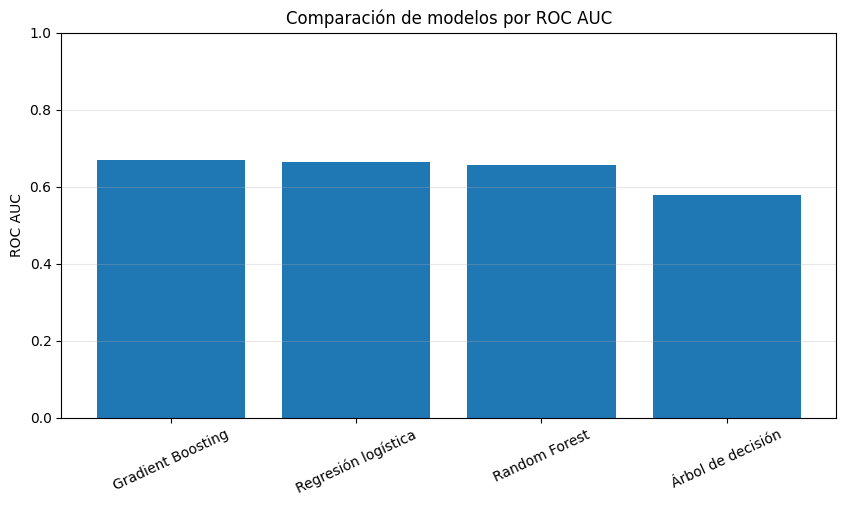

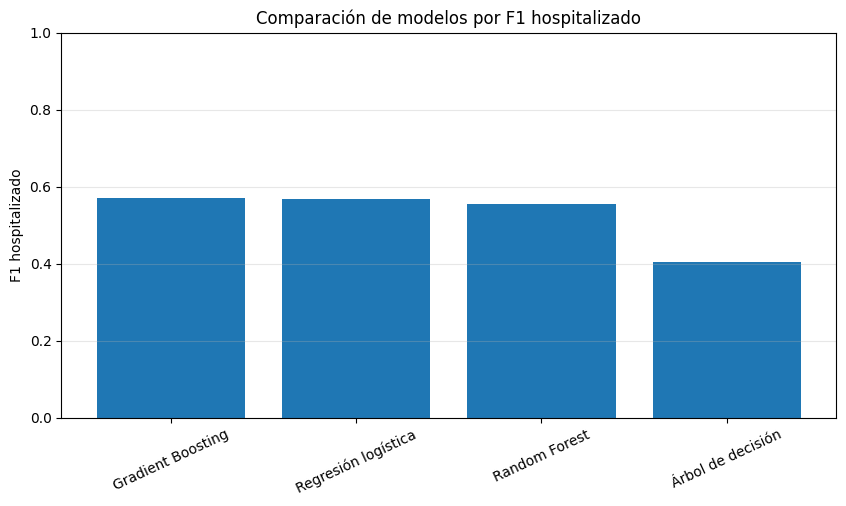

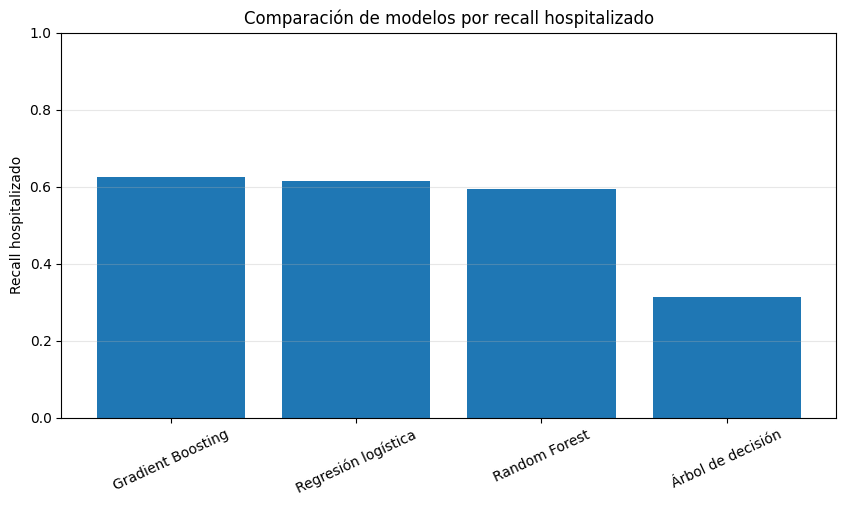

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(tabla_resultados["modelo"], tabla_resultados["roc_auc"])
plt.title("Comparación de modelos por ROC AUC")
plt.ylabel("ROC AUC")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(tabla_resultados["modelo"], tabla_resultados["f1_hospitalizado"])
plt.title("Comparación de modelos por F1 hospitalizado")
plt.ylabel("F1 hospitalizado")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(tabla_resultados["modelo"], tabla_resultados["recall_hospitalizado"])
plt.title("Comparación de modelos por recall hospitalizado")
plt.ylabel("Recall hospitalizado")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 13. Mejor modelo y matriz de confusión

Se toma el modelo con mejor resultado en la tabla y se revisa su matriz de confusión.


In [13]:
mejor_nombre = tabla_resultados.iloc[0]["modelo"]
mejor_modelo = modelos_entrenados[mejor_nombre]

prob_mejor = mejor_modelo.predict_proba(X_test)[:, 1]
pred_mejor = (prob_mejor >= umbral).astype(int)

print("Mejor modelo:", mejor_nombre)

display(pd.DataFrame(
    confusion_matrix(y_test, pred_mejor),
    index=["Real ambulatorio", "Real hospitalizado"],
    columns=["Predicho ambulatorio", "Predicho hospitalizado"]
))

print(classification_report(
    y_test,
    pred_mejor,
    target_names=["Ambulatorio", "Hospitalizado"],
    zero_division=0
))


Mejor modelo: Gradient Boosting


,Predicho ambulatorio,Predicho hospitalizado
Real ambulatorio,15501,9657
Real hospitalizado,6460,10769


               precision    recall  f1-score   support

  Ambulatorio       0.71      0.62      0.66     25158
Hospitalizado       0.53      0.63      0.57     17229

     accuracy                           0.62     42387
    macro avg       0.62      0.62      0.61     42387
 weighted avg       0.63      0.62      0.62     42387



## 14. Función para probar pacientes

Esta función permite ingresar los datos de un paciente y obtener una predicción estimada.


In [28]:
def grupo_edad(edad):
    return pd.cut(pd.Series([edad]), bins=bins_edad, labels=labels_edad).iloc[0]

def probar_paciente(edad, entidad_res, hemorragicos, diabetes, hipertension, enfermedad_renal, inmunosupresion, embarazo):
    paciente = pd.DataFrame([{
        "EDAD_GRUPO": grupo_edad(edad),
        "ENTIDAD_RES": str(entidad_res),
        "HEMORRAGICOS": hemorragicos,
        "DIABETES": diabetes,
        "HIPERTENSION": hipertension,
        "ENFERMEDAD_RENAL": enfermedad_renal,
        "INMUNOSUPR": inmunosupresion,
        "EMBARAZO": embarazo
    }])

    prob_hosp = mejor_modelo.predict_proba(paciente)[0, 1]
    prob_amb = 1 - prob_hosp

    if prob_hosp < 0.30:
        riesgo = "Bajo"
    elif prob_hosp < 0.60:
        riesgo = "Medio"
    else:
        riesgo = "Alto"

    return {
        "modelo": mejor_nombre,
        "edad": edad,
        "grupo_edad": grupo_edad(edad),
        "entidad_res": entidad_res,
        "hemorragicos": hemorragicos,
        "diabetes": diabetes,
        "hipertension": hipertension,
        "enfermedad_renal": enfermedad_renal,
        "inmunosupresion": inmunosupresion,
        "embarazo": embarazo,
        "prob_hospitalizacion_%": round(prob_hosp * 100, 2),
        "prob_ambulatorio_%": round(prob_amb * 100, 2),
        "clasificacion": "Hospitalizado" if prob_hosp >= umbral else "Ambulatorio",
        "riesgo": riesgo
    }


### 15. Pruebas con 15 pacientes

Se hacen 15 pruebas con diferentes edades, entidades y padecimientos.


In [29]:
pruebas = pd.DataFrame([
    probar_paciente(8, 9, 0, 0, 0, 0, 0, 0),
    probar_paciente(15, 12, 1, 0, 0, 0, 0, 0),
    probar_paciente(22, 14, 0, 0, 0, 0, 0, 0),
    probar_paciente(28, 15, 1, 0, 0, 0, 0, 1),
    probar_paciente(34, 21, 0, 1, 0, 0, 0, 0),
    probar_paciente(42, 30, 1, 1, 0, 0, 0, 0),
    probar_paciente(48, 7, 0, 1, 1, 0, 0, 0),
    probar_paciente(53, 23, 1, 0, 1, 0, 0, 0),
    probar_paciente(59, 27, 1, 1, 1, 0, 0, 0),
    probar_paciente(63, 20, 0, 1, 1, 1, 0, 0),
    probar_paciente(67, 31, 1, 0, 1, 1, 0, 0),
    probar_paciente(72, 5, 1, 1, 1, 1, 0, 0),
    probar_paciente(76, 16, 0, 1, 1, 0, 1, 0),
    probar_paciente(81, 25, 1, 1, 1, 0, 1, 0),
    probar_paciente(88, 19, 1, 1, 1, 1, 1, 0)
])

display(pruebas)


,modelo,edad,grupo_edad,entidad_res,hemorragicos,diabetes,hipertension,enfermedad_renal,inmunosupresion,embarazo,prob_hospitalizacion_%,prob_ambulatorio_%,clasificacion,riesgo
0,Gradient Boosting,8,0-9,9,0,0,0,0,0,0,38.68,61.32,Ambulatorio,Medio
1,Gradient Boosting,15,10-19,12,1,0,0,0,0,0,81.47,18.53,Hospitalizado,Alto
2,Gradient Boosting,22,20-29,14,0,0,0,0,0,0,29.79,70.21,Ambulatorio,Bajo
3,Gradient Boosting,28,20-29,15,1,0,0,0,0,1,48.92,51.08,Hospitalizado,Medio
4,Gradient Boosting,34,30-39,21,0,1,0,0,0,0,48.30,51.70,Hospitalizado,Medio
5,Gradient Boosting,42,40-49,30,1,1,0,0,0,0,59.24,40.76,Hospitalizado,Medio
6,Gradient Boosting,48,40-49,7,0,1,1,0,0,0,57.81,42.19,Hospitalizado,Medio
7,Gradient Boosting,53,50-59,23,1,0,1,0,0,0,68.96,31.04,Hospitalizado,Alto
8,Gradient Boosting,59,50-59,27,1,1,1,0,0,0,60.55,39.45,Hospitalizado,Alto
9,Gradient Boosting,63,60-69,20,0,1,1,1,0,0,86.01,13.99,Hospitalizado,Alto


## Conclusión

El proyecto permite comparar modelos y probar predicciones estimadas con distintos perfiles de pacientes.  
Los resultados son para análisis académico y no representan diagnóstico médico.

video del proyecto: https://drive.google.com/file/d/1y7wTf5WlTx460jOzA7xlpssLR-BAjbAB/view?usp=sharing
